In [ ]:
!pip install git+https://github.com/Starlitnightly/dynamo-release.git

In [1]:
import dynamo as dyn
dyn.configuration.set_figure_params('dynamo', background='white')
print(f'dynamo version: {dyn.__version__}')

/home/groups/xiaojie/steorra/env/omicverse/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/groups/xiaojie/steorra/env/omicverse/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/groups/xiaojie/steorra/env/omicverse/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/home/groups/xiaojie/steorra/env/omicverse/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/groups/xiaojie/steorra/env/omicverse/lib/python3.10/site-packages/an

dynamo version: 1.4.2rc1


/home/groups/xiaojie/steorra/env/omicverse/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


In [2]:
dyn.pl.style()



 ███                               ████████        
█████   █████    █████    █████    ███   █████      
   ██████   ██████   ██████   ████████      ████ 
  ___                           ████            ███
 |   \ _  _ _ _  __ _ _ __  ___                 ███
 | |) | || | ' \/ _` | '  \/ _ \█████           ███ 
 |___/ \_, |_||_\__,_|_|_|_\___/█████       ████  
       |__/                        ███   █████     
Tutorial: https://dynamo-release.readthedocs.io/       
                                     █████      



In [3]:
adata=dyn.sample_data.pancreatic_endocrinogenesis()
adata

|-----> Downloading data to ./data/endocrinogenesis_day15.h5ad
|-----> File ./data/endocrinogenesis_day15.h5ad already exists.


AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced'
    obsp: 'distances', 'connectivities'

In [4]:
adata.layers['counts']=adata.X.copy()

In [5]:
preprocessor = dyn.pp.Preprocessor(cell_cycle_score_enable=True)
preprocessor.preprocess_adata(adata, recipe='monocle')

|-----> Running monocle preprocessing pipeline...
|-----------> filtered out 0 outlier cells
|-----------> filtered out 21736 outlier genes
|-----> PCA dimension reduction
|-----> <insert> X_pca to obsm in AnnData Object.
|-----> computing cell phase...
|-----> [Cell Phase Estimation] completed [39.2669s]
|-----> [Cell Cycle Scores Estimation] completed [0.4746s]
|-----> [Preprocessor-monocle] completed [25.6415s]


In [6]:
#dyn.tl.dynamics(adata, model='stochastic', cores=3) 
# or dyn.tl.dynamics(adata, model='deterministic')
dyn.tl.dynamics(adata, #filter_gene_mode='basic',
                model='auto', est_method='auto',
                #sanity_check=True,
               cores=8)


|-----> dynamics_del_2nd_moments_key is None. Using default value from DynamoAdataConfig: dynamics_del_2nd_moments_key=False
|-----------> removing existing M layers:[]...
|-----------> making adata smooth...
|-----> calculating first/second moments...
|-----? layer X_counts is not in any of the (['X_spliced', 'X_unspliced'], ['X_new', 'X_total'], ['X_uu', 'X_ul', 'X_su', 'X_sl']) groups, skipping...
|-----? layer X_counts is not in any of the (['X_spliced', 'X_unspliced'], ['X_new', 'X_total'], ['X_uu', 'X_ul', 'X_su', 'X_sl']) groups, skipping...
|-----? layer X_counts is not in any of the (['X_spliced', 'X_unspliced'], ['X_new', 'X_total'], ['X_uu', 'X_ul', 'X_su', 'X_sl']) groups, skipping...
|-----> [moments calculation] completed [28.1842s]


AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'nGenes', 'nCounts', 'pMito', 'pass_basic_filter', 'Size_Factor', 'initial_cell_size', 'unspliced_Size_Factor', 'initial_unspliced_cell_size', 'spliced_Size_Factor', 'initial_spliced_cell_size', 'counts_Size_Factor', 'initial_counts_cell_size', 'ntr', 'cell_cycle_phase'
    var: 'highly_variable_genes', 'nCells', 'nCounts', 'pass_basic_filter', 'log_cv', 'log_m', 'score', 'frac', 'use_for_pca', 'ntr', 'use_for_dynamics'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'pp', 'velocyto_SVR', 'feature_selection', 'PCs', 'explained_variance_ratio_', 'pca_mean', 'cell_phase_order', 'cell_phase_genes', 'vel_params_names', 'dynamics'
    obsm: 'X_pca', 'X_umap', 'cell_cycle_scores'
    varm: 'vel_params'
    layers: 'spliced', 'unspliced', 'counts', 'X_counts', 'X_unspliced', 'X_spliced', 'M_u', 'M_uu', 'M_s', 'M_us', 'M_ss', 'velocity_S'
   

|-----> retrieve data for non-linear dimension reduction...
|-----? adata already have basis umap. dimension reduction umap will be skipped! 
set enforce=True to re-performing dimension reduction.
|-----> [UMAP] completed [0.0033s]
|-----------> plotting with basis key=X_umap
|-----------> skip filtering clusters by stack threshold when stacking color because it is not a numeric type


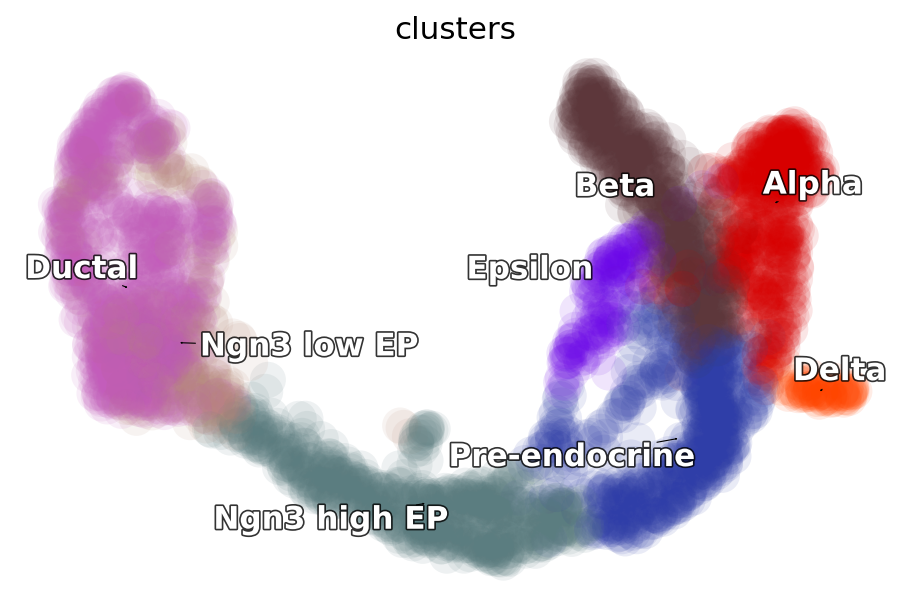

In [7]:
dyn.tl.reduceDimension(adata)

dyn.pl.umap(adata, color='clusters',
           save_show_or_return='show',
            adjust_legend=True)

In [8]:
dyn.tl.cell_velocities(adata, method='pearson', 
                       other_kernels_dict={'transform': 'sqrt'}
                      )

|-----> [calculating transition matrix via pearson kernel with sqrt transform.] in progress: 100.0000%|-----> [calculating transition matrix via pearson kernel with sqrt transform.] completed [3.4653s]
|-----> [projecting velocity vector to low dimensional embedding] in progress: 100.0000%|-----> [projecting velocity vector to low dimensional embedding] completed [0.7365s]
|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected


AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'nGenes', 'nCounts', 'pMito', 'pass_basic_filter', 'Size_Factor', 'initial_cell_size', 'unspliced_Size_Factor', 'initial_unspliced_cell_size', 'spliced_Size_Factor', 'initial_spliced_cell_size', 'counts_Size_Factor', 'initial_counts_cell_size', 'ntr', 'cell_cycle_phase'
    var: 'highly_variable_genes', 'nCells', 'nCounts', 'pass_basic_filter', 'log_cv', 'log_m', 'score', 'frac', 'use_for_pca', 'ntr', 'use_for_dynamics', 'use_for_transition'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'pp', 'velocyto_SVR', 'feature_selection', 'PCs', 'explained_variance_ratio_', 'pca_mean', 'cell_phase_order', 'cell_phase_genes', 'vel_params_names', 'dynamics', 'grid_velocity_umap'
    obsm: 'X_pca', 'X_umap', 'cell_cycle_scores', 'velocity_umap'
    varm: 'vel_params'
    layers: 'spliced', 'unspliced', 'counts', 'X_counts', 'X_unspliced', 'X_spl

|-----> X shape: (3696, 2) V shape: (3696, 2)
|-----------> plotting with basis key=X_umap
|-----------> skip filtering clusters by stack threshold when stacking color because it is not a numeric type


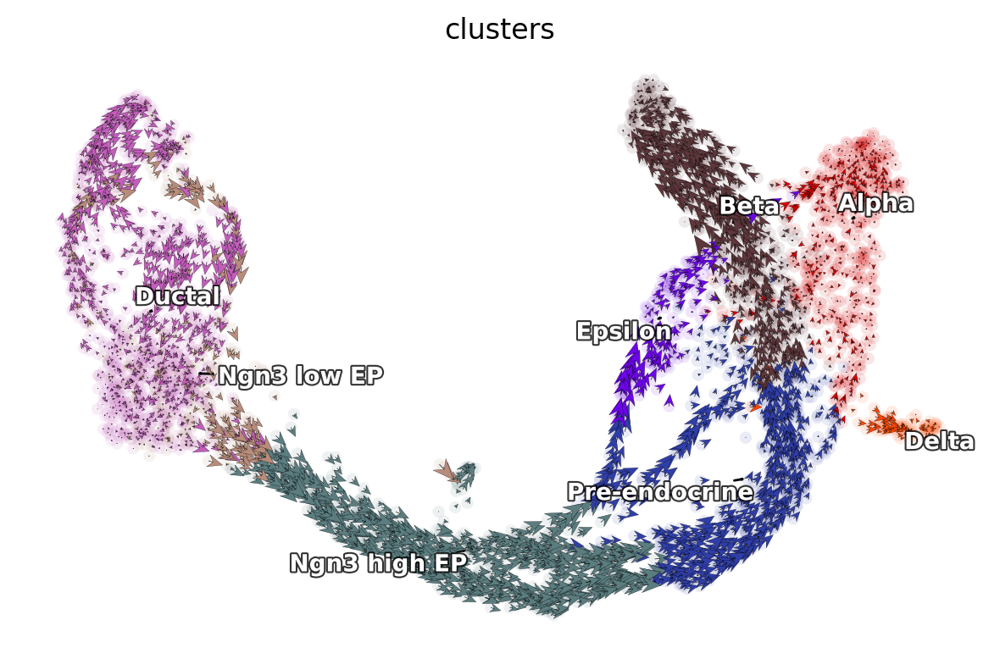

In [9]:
dyn.pl.cell_wise_vectors(adata, color=['clusters'], basis='umap', 
                         show_legend='on data', quiver_length=6, 
                         quiver_size=6, pointsize=0.1, 
                         s_kwargs_dict={'adjust_legend':True},
                         show_arrowed_spines=False)


|-----> X shape: (3696, 2) V shape: (3696, 2)
|-----------> plotting with basis key=X_umap
|-----------> skip filtering clusters by stack threshold when stacking color because it is not a numeric type


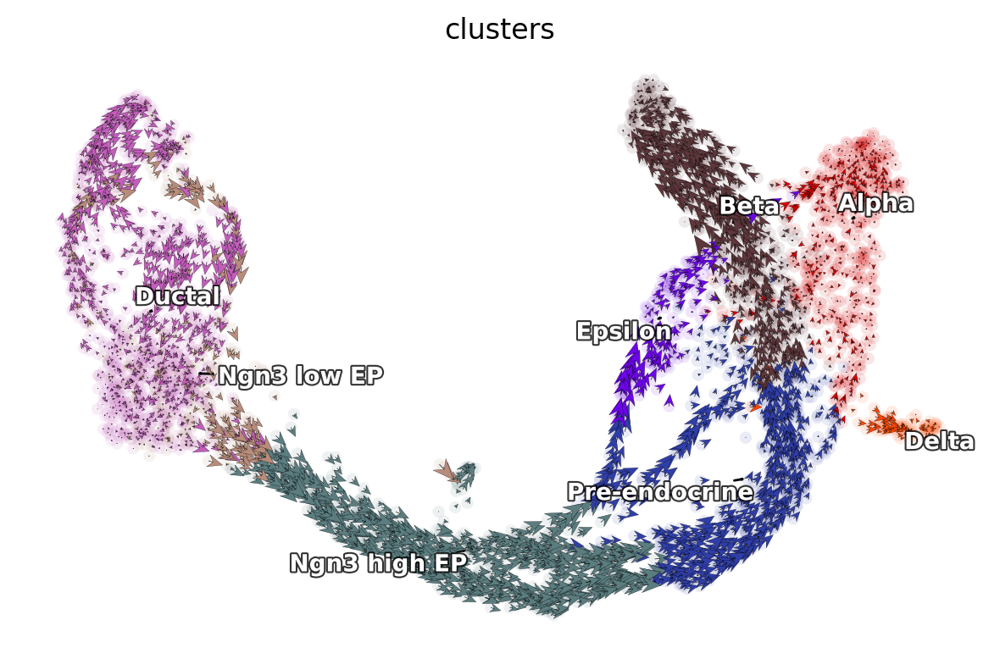

In [10]:
dyn.pl.cell_wise_vectors(adata, color=['clusters'], basis='umap', 
                         show_legend='on data', quiver_length=6, 
                         quiver_size=6, pointsize=0.1, 
                         s_kwargs_dict={'adjust_legend':True},
                         show_arrowed_spines=False)


|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----------> plotting with basis key=X_umap
|-----------> skip filtering clusters by stack threshold when stacking color because it is not a numeric type


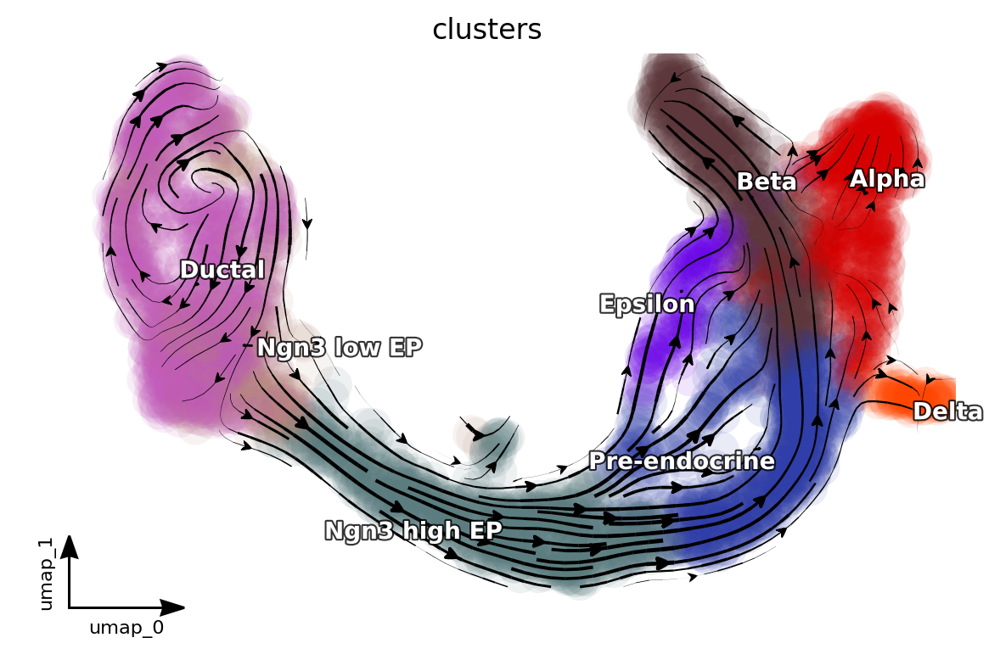

In [11]:
dyn.pl.streamline_plot(adata, color=['clusters'], 
                       basis='umap', show_legend='on data', 
                       s_kwargs_dict={'adjust_legend':True},
                       show_arrowed_spines=True)

|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----------> plotting with basis key=X_umap


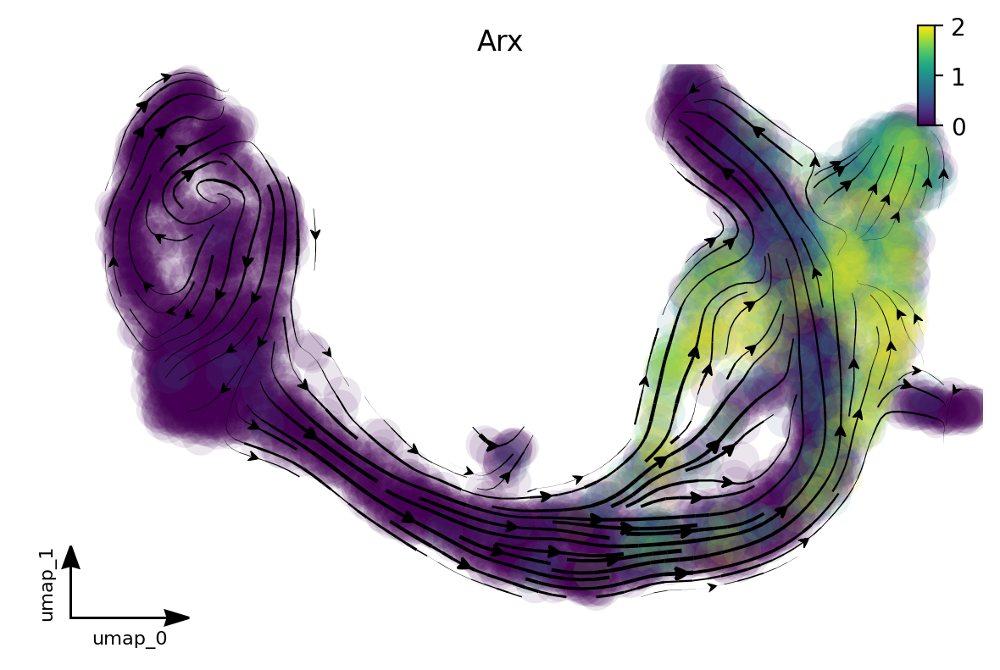

In [12]:
dyn.pl.streamline_plot(adata, color=['Arx'], 
                       basis='umap', show_legend='on data', 
                       s_kwargs_dict={'adjust_legend':True},
                       show_arrowed_spines=True)

|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----------> plotting with basis key=X_umap


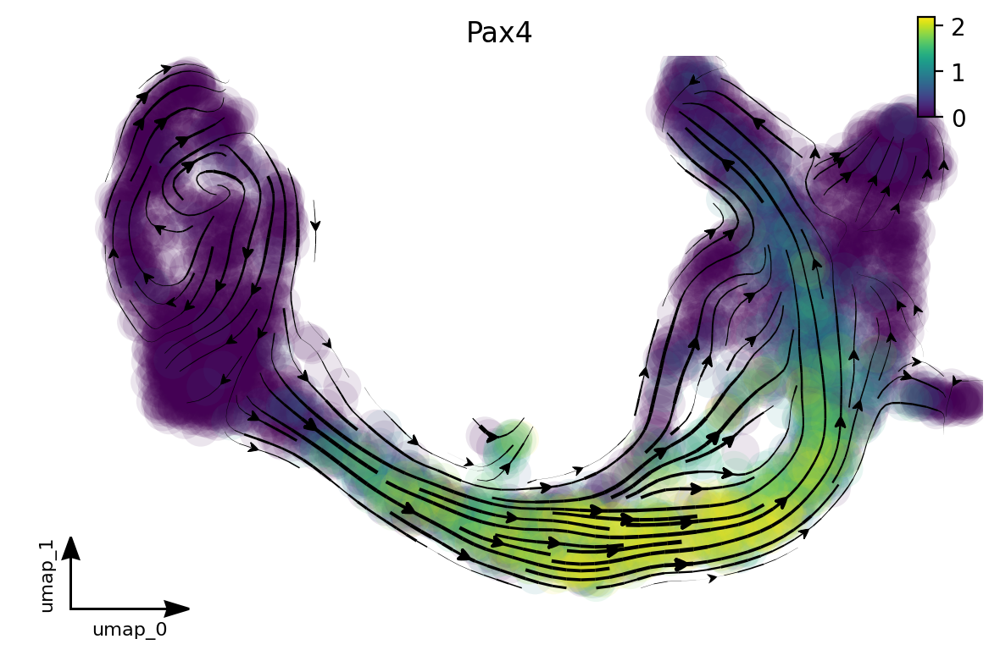

In [13]:
dyn.pl.streamline_plot(adata, color=['Pax4'], 
                       basis='umap', show_legend='on data', 
                       s_kwargs_dict={'adjust_legend':True},
                       show_arrowed_spines=True)

|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----------> plotting with basis key=X_umap
|-----------> skip filtering clusters by stack threshold when stacking color because it is not a numeric type


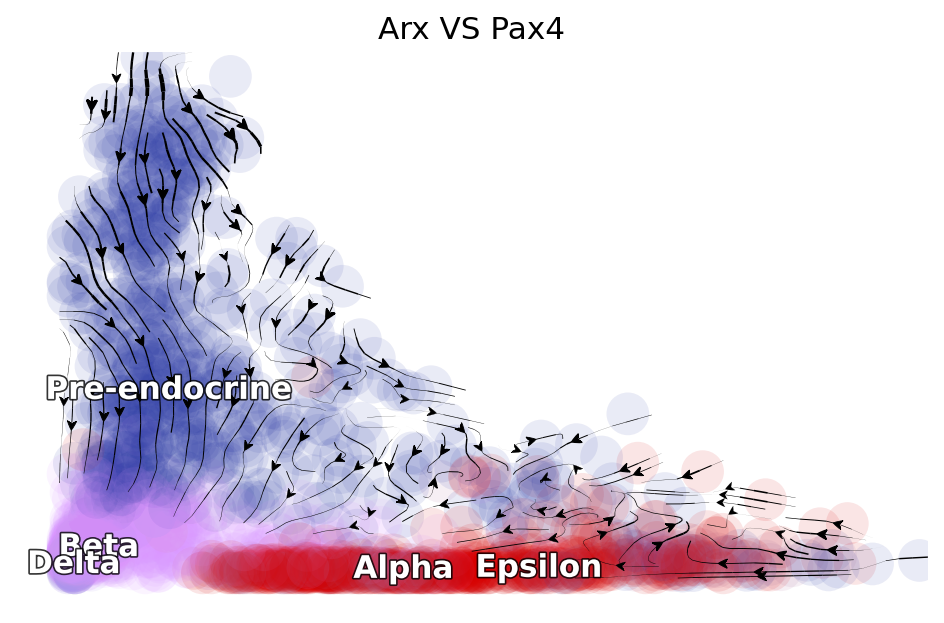

In [14]:
%matplotlib inline
dyn.pl.style()
dyn.pl.streamline_plot(
    adata[adata.obs['clusters'].isin([
        'Pre-endocrine','Alpha','Beta','Epsilon','Delta'
    ])],
    color="clusters",
    x="Arx",
    y="Pax4",
    layer="M_s",
    ekey="M_s",
    #vkey="velocity_alpha_minus_gamma_s",
)

In [35]:
# you can set `verbose = 1/2/3` to obtain different levels of running information of vector field reconstruction
dyn.vf.VectorField(adata, basis='umap', M=100, pot_curl_div=True) 


|-----> VectorField reconstruction begins...
|-----> Retrieve X and V based on basis: UMAP. 
        Vector field will be learned in the UMAP space.
|-----> Generating high dimensional grids and convert into a row matrix.
|-----> Learning vector field with method: sparsevfc.
|-----> [SparseVFC] begins...
|-----> Sampling control points based on data velocity magnitude...
|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----> [SparseVFC] completed [6.0588s]
|-----> Running ddhodge to estimate vector field based pseudotime in umap basis...
|-----> fetch computation results from adata.obsp[umap_ddhodge]...
|-----> [ddhodge completed] completed [13.7325s]
|-----> Computing curl...


Calculating 2-D curl: 100%|██████████| 3696/3696 [00:00<00:00, 23974.57it/s]

|-----> Computing divergence...



Calculating divergence: 100%|██████████| 4/4 [00:00<00:00, 29.61it/s]


|-----> [VectorField] completed [20.4416s]


|-----> Vector field for umap is but its topography is not mapped. Mapping topography now ...
|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----------> plotting with basis key=X_umap
|-----------> skip filtering clusters by stack threshold when stacking color because it is not a numeric type


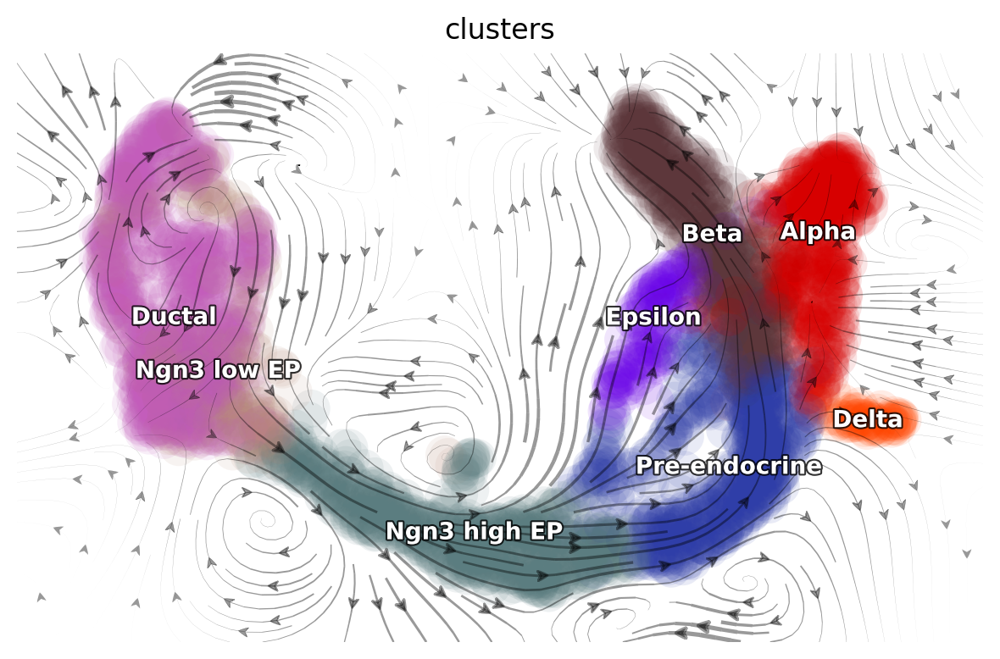

In [16]:
dyn.pl.topography(adata, color=['clusters'], basis='umap', background='white',
                  streamline_color='black', #color_key = pancreas_cluster_cmap,
                  show_legend='on data', terms=("streamline"))


|-----------> plotting with basis key=X_umap
|-----------> skip filtering clusters by stack threshold when stacking color because it is not a numeric type


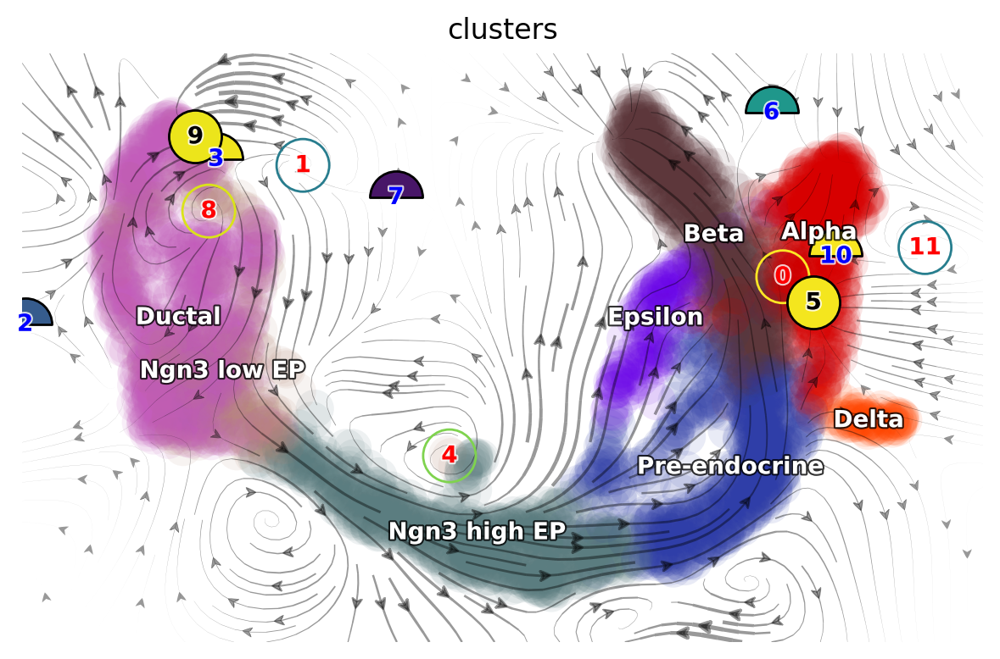

In [17]:
dyn.pl.topography(
    adata,
    markersize=500,
    basis="umap",
    fps_basis="umap",
    #color_key = pancreas_cluster_cmap,
    color=["clusters"],
    show_legend='on data',
    save_show_or_return='show'
)

|-----------> plotting with basis key=X_umap
|-----------> skip filtering clusters by stack threshold when stacking color because it is not a numeric type


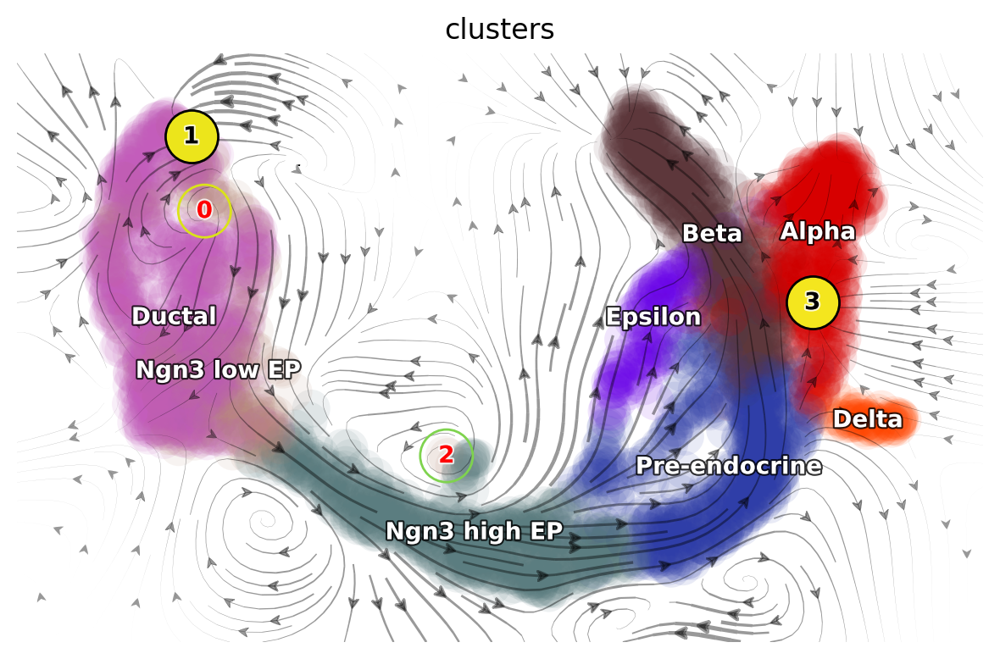

In [18]:
adata_load_fix_points=adata.copy()
Xss, ftype, conf = adata_load_fix_points.uns['VecFld_umap']['Xss'],\
                   adata_load_fix_points.uns['VecFld_umap']['ftype'],\
                   adata_load_fix_points.uns['VecFld_umap']['confidence']

fixed_points = [8,9,4,5]

adata_load_fix_points.uns['VecFld_umap']['Xss'] = Xss[fixed_points]
adata_load_fix_points.uns['VecFld_umap']['ftype'] = ftype[fixed_points]
adata_load_fix_points.uns['VecFld_umap']['confidence']=conf[fixed_points]

dyn.pl.topography(
    adata_load_fix_points,
    markersize=500,
    basis="umap",
    fps_basis="umap",
    #color_key = pancreas_cluster_cmap,
    color=["clusters"],
    show_legend='on data',
    save_show_or_return='show'
)

In [19]:
dyn.tl.cell_velocities(adata, basis="umap")

Using existing pearson_transition_matrix found in .obsp.
|-----> [projecting velocity vector to low dimensional embedding] in progress: 100.0000%|-----> [projecting velocity vector to low dimensional embedding] completed [0.8354s]
|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected


AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'nGenes', 'nCounts', 'pMito', 'pass_basic_filter', 'Size_Factor', 'initial_cell_size', 'unspliced_Size_Factor', 'initial_unspliced_cell_size', 'spliced_Size_Factor', 'initial_spliced_cell_size', 'counts_Size_Factor', 'initial_counts_cell_size', 'ntr', 'cell_cycle_phase', 'umap_ddhodge_div', 'umap_ddhodge_potential', 'curl_umap', 'divergence_umap', 'control_point_umap', 'inlier_prob_umap', 'obs_vf_angle_umap'
    var: 'highly_variable_genes', 'nCells', 'nCounts', 'pass_basic_filter', 'log_cv', 'log_m', 'score', 'frac', 'use_for_pca', 'ntr', 'use_for_dynamics', 'use_for_transition'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'pp', 'velocyto_SVR', 'feature_selection', 'PCs', 'explained_variance_ratio_', 'pca_mean', 'cell_phase_order', 'cell_phase_genes', 'vel_params_names', 'dynamics', 'grid_velocity_umap', 'VecFld_umap'
    obsm: 'X

In [21]:
dyn.tl.cell_velocities(adata, basis="pca")
dyn.vf.VectorField(adata, basis='pca') 

Using existing pearson_transition_matrix found in .obsp.
|-----> [projecting velocity vector to low dimensional embedding] in progress: 100.0000%|-----> [projecting velocity vector to low dimensional embedding] completed [0.9059s]
|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----> VectorField reconstruction begins...
|-----> Retrieve X and V based on basis: PCA. 
        Vector field will be learned in the PCA space.
|-----> Learning vector field with method: sparsevfc.
|-----> [SparseVFC] begins...
|-----> Sampling control points based on data velocity magnitude...
|-----> method arg is None, choosing methods automatically...
|-----------> method ball_tree selected
|-----> [SparseVFC] completed [4.0248s]
|-----> [VectorField] completed [4.1873s]


Transforming subset Jacobian: 100%|██████████| 3696/3696 [00:00<00:00, 87115.19it/s]


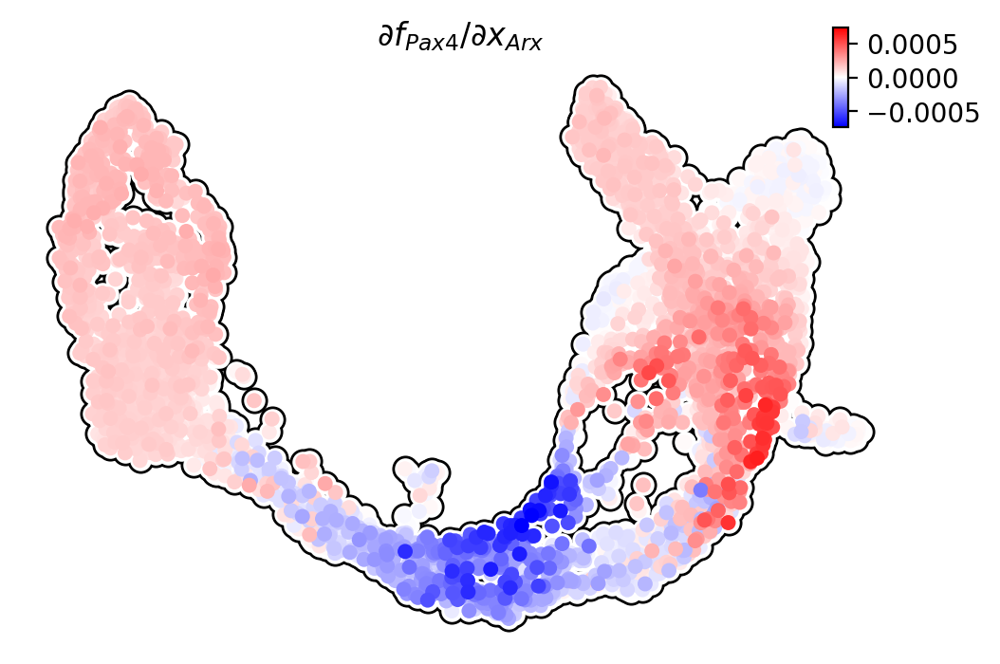

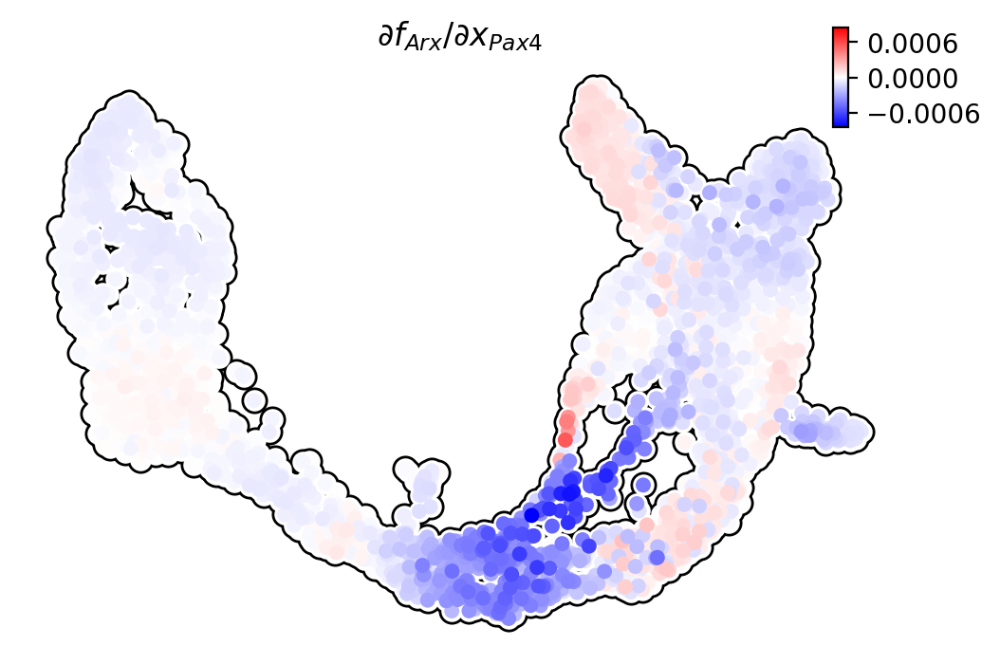

In [22]:
dyn.vf.jacobian(adata, regulators=['Arx','Pax4'])

dyn.pl.jacobian(
    adata,
    basis="umap",
    regulators=['Arx'],
    effectors=['Pax4'],
    alpha=1,
)

dyn.pl.jacobian(
    adata,
    basis="umap",
    regulators=['Pax4'],
    effectors=['Arx'],
    alpha=1,
)

|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----------> plotting with basis key=X_umap
|-----------> skip filtering clusters by stack threshold when stacking color because it is not a numeric type


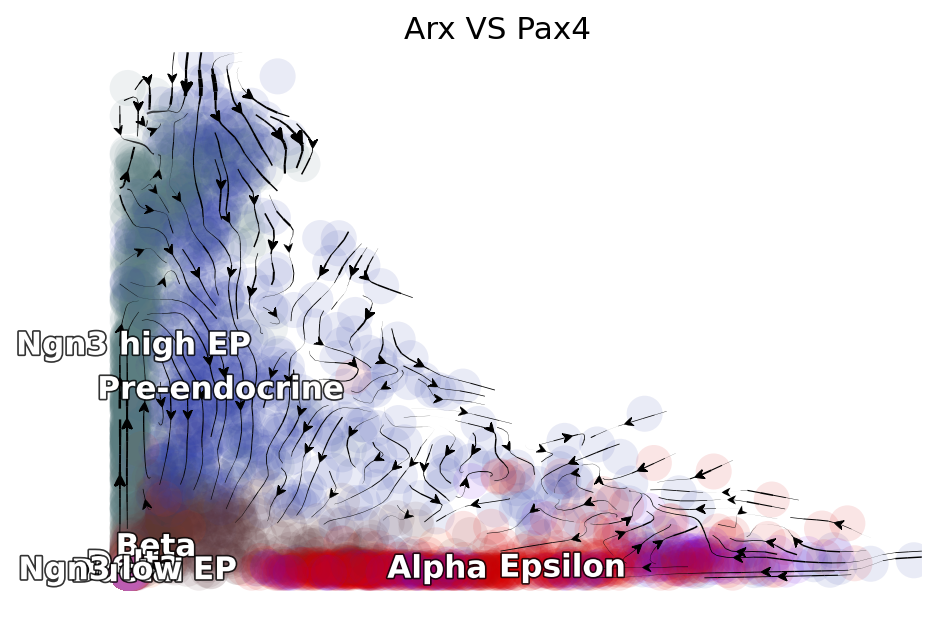

In [23]:
%matplotlib inline
dyn.pl.style()
dyn.pl.streamline_plot(
    adata,
    color="clusters",
    x="Arx",
    y="Pax4",
    layer="M_s",
    ekey="M_s",
    #vkey="velocity_alpha_minus_gamma_s",
)

|-----------> plotting with basis key=X_umap
|-----------> plotting with basis key=X_umap


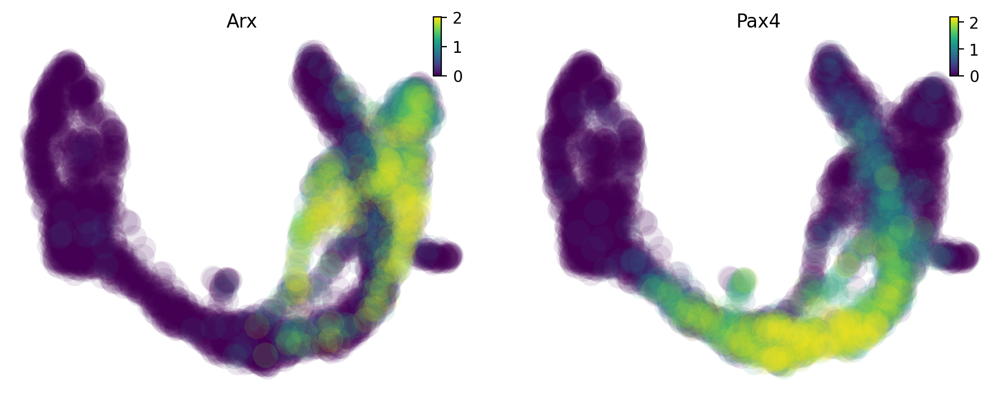

In [24]:
dyn.pl.umap(adata,  color=["Arx",'Pax4'],save_show_or_return='show')

|-----------> plotting with basis key=X_umap
|-----------> skip filtering clusters by stack threshold when stacking color because it is not a numeric type


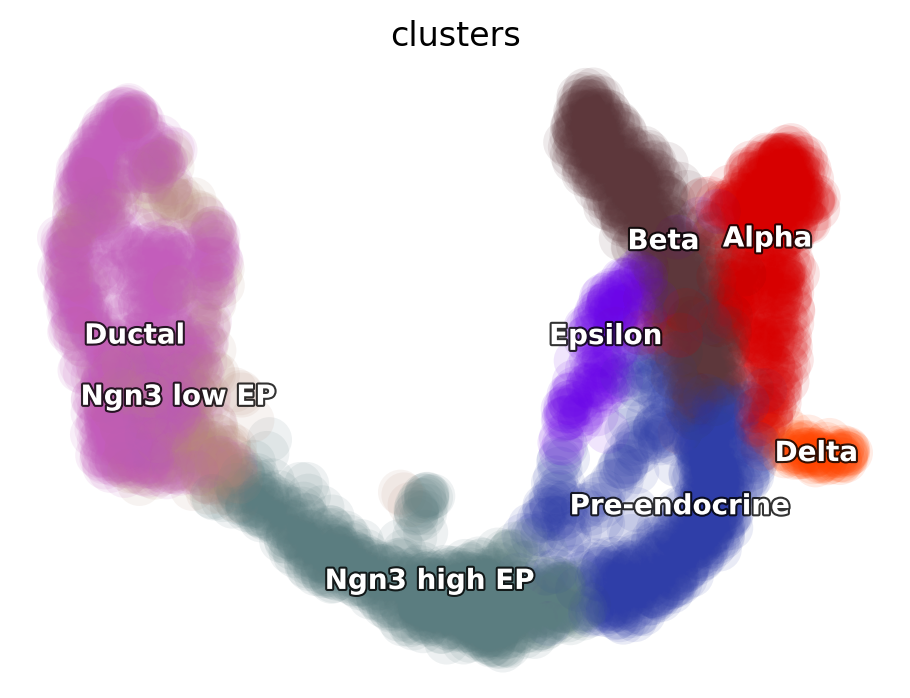

In [29]:
dyn.pl.umap(adata,
               color='clusters',)

In [30]:
pancreas_cluster_cmap = {'Ductal': '#3361A5',
                         'Ngn3 low EP': '#248AF3',
                         'Ngn3 high EP': '#14B3FF',
                         'Pre-endocrine': '#88CEEF',
                         'Alpha': '#ff4800',
                         'Beta': '#B81136',
                         'Delta': 'green',
                         'Epsilon': '#03B3B0'}


In [31]:
color_dict=dict(zip(
    adata.obs['clusters'].cat.categories,
    adata.uns['clusters_colors']
))

In [32]:
adata.obs['clusters'].cat.categories

Index(['Ductal', 'Ngn3 low EP', 'Ngn3 high EP', 'Pre-endocrine', 'Beta',
       'Alpha', 'Delta', 'Epsilon'],
      dtype='object')

|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----------> plotting with basis key=X_umap
|-----------> skip filtering clusters by stack threshold when stacking color because it is not a numeric type


Text(0.5, 1.0, 'Pancera:CellType[Ms/Mu]')

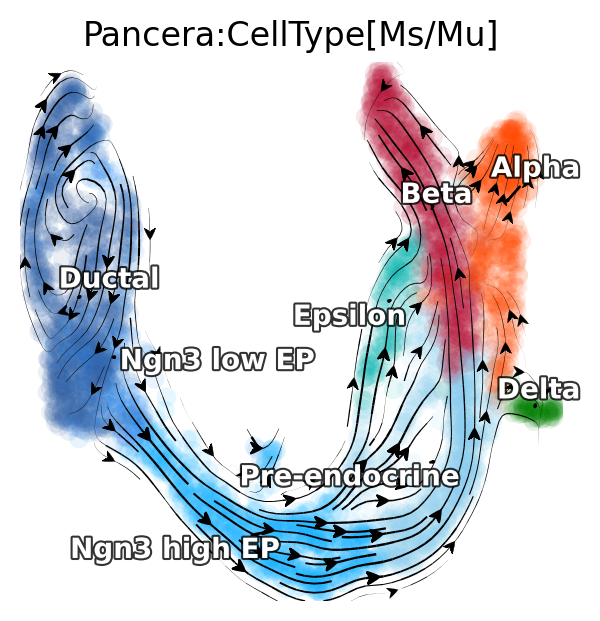

In [33]:
%matplotlib inline
import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,1,figsize = (3.5,3.5))
dyn.pl.streamline_plot(adata, color=['clusters'], 
                       color_key=pancreas_cluster_cmap,
                       title='Pancera:CellType',
                       basis='umap', show_legend='on data', 
                       s_kwargs_dict={'adjust_legend':True,
                                     's':50},
                       linewidth=0.5,
                       #show_arrowed_spines=True,
                      save_show_or_return='return',ax=ax)
plt.title('Pancera:CellType[Ms/Mu]',fontsize=12)
#fig.savefig(f'figures/fig3/Ms_Mu_HSC_Velo.png', dpi=300, bbox_inches='tight')

In [115]:
# you can set `verbose = 1/2/3` to obtain different levels of running information of vector field reconstruction
#dyn.vf.VectorField(adata, basis='umap', M=100, pot_curl_div=True) 

|-----> VectorField reconstruction begins...
|-----> Retrieve X and V based on basis: UMAP. 
        Vector field will be learned in the UMAP space.
|-----> Generating high dimensional grids and convert into a row matrix.
|-----> Learning vector field with method: sparsevfc.
|-----> [SparseVFC] begins...
|-----> Sampling control points based on data velocity magnitude...
|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----> [SparseVFC] completed [21.3202s]
|-----> Running ddhodge to estimate vector field based pseudotime in umap basis...
|-----> graphizing vectorfield...
|-----------> calculating neighbor indices...
|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----------> not all cells are used, set diag to 1...
|-----------> Constructing W matrix according upsampling=True and downsampling=True options...
|-----> [ddhodge completed] completed [34.1372s]
|-----> Computing curl.

Calculating 2-D curl: 100%|██████████████| 5292/5292 [00:00<00:00, 23730.10it/s]

|-----> Computing divergence...



Calculating divergence: 100%|█████████████████████| 6/6 [00:00<00:00, 37.91it/s]


|-----> [VectorField] completed [55.9898s]


|-----------> plotting with basis key=X_umap
|-----------> skip filtering clusters by stack threshold when stacking color because it is not a numeric type


Text(0.5, 1.0, 'Pancera:Topography[Ms/Mu]')

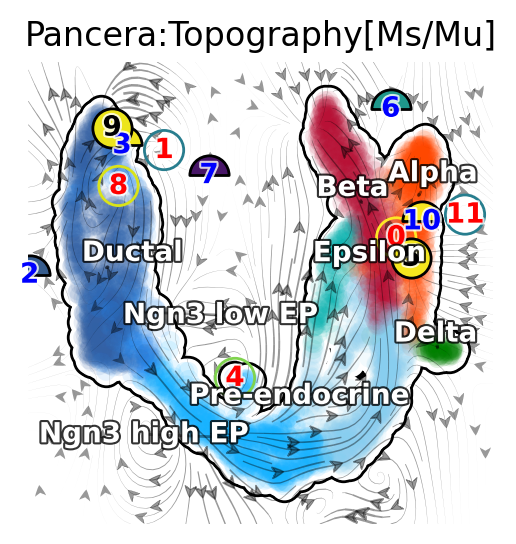

In [37]:
%matplotlib inline
import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,1,figsize = (3,3))
dyn.pl.topography(adata, basis='umap', background='white', 
                  color=[ 'clusters'], 
                  color_key=pancreas_cluster_cmap,
                  streamline_color='black',
                  s_kwargs_dict={'adjust_legend':True,
                                     's':50},
                  linewidth=0.5,
                  show_legend='on data', frontier=True,
                 save_show_or_return='return',ax=ax)
plt.title('Pancera:Topography[Ms/Mu]',fontsize=12)
#fig.savefig(f'figures/fig3/Ms_Mu_HSC_Topography.png', dpi=300, bbox_inches='tight')

|-----------> plotting with basis key=X_umap
|-----------> skip filtering clusters by stack threshold when stacking color because it is not a numeric type


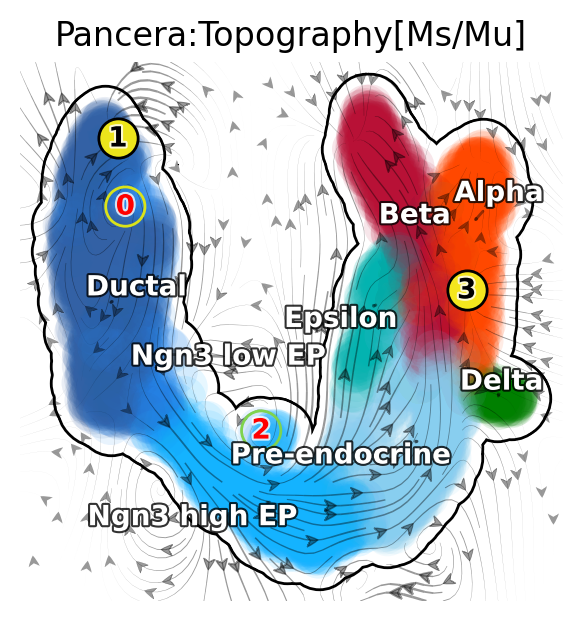

In [38]:
adata_load_fix_points=adata.copy()
Xss, ftype, conf = adata_load_fix_points.uns['VecFld_umap']['Xss'],\
                   adata_load_fix_points.uns['VecFld_umap']['ftype'],\
                   adata_load_fix_points.uns['VecFld_umap']['confidence']

fixed_points = [8,9,4,5]

adata_load_fix_points.uns['VecFld_umap']['Xss'] = Xss[fixed_points]
adata_load_fix_points.uns['VecFld_umap']['ftype'] = ftype[fixed_points]
adata_load_fix_points.uns['VecFld_umap']['confidence']=conf[fixed_points]

import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,1,figsize = (3.5,3.5))
#ov.plot_set()
dyn.pl.topography(adata_load_fix_points, basis='umap',
                  fps_basis='umap',background='white', 
                  color=[ 'clusters'], 
                  color_key=pancreas_cluster_cmap,
                  streamline_color='black',
                  s_kwargs_dict={'adjust_legend':True,
                                    },
                  linewidth=0.5,
                  show_legend='on data', frontier=True,
                 save_show_or_return='return',ax=ax)
plt.title('Pancera:Topography[Ms/Mu]',fontsize=12)
#fig.savefig(f'figures/fig3/Ms_Mu_HSC_Topography.png', dpi=300, bbox_inches='tight')
fig

|-----------> plotting with basis key=X_umap


Text(0.5, 1.0, 'Pancera:Potential[Ms/Mu]')

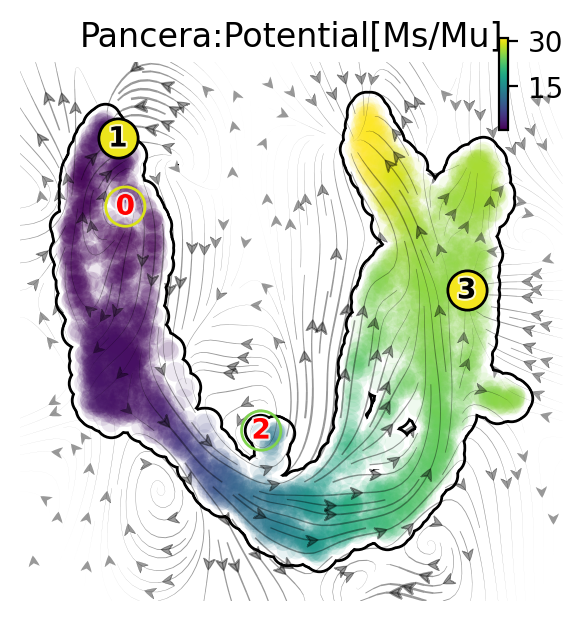

In [40]:
%matplotlib inline
import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,1,figsize = (3.5,3.5))
dyn.pl.topography(adata_load_fix_points, basis='umap', background='white', 
                  color=[ 'umap_ddhodge_potential'], 
                  #color_key=color_dict,
                  streamline_color='black',
                  s_kwargs_dict={'adjust_legend':True,
                                     's':50},
                  linewidth=0.5,
                  show_legend='on data', frontier=True,
                 save_show_or_return='return',ax=ax)
ax.set_title('Pancera:Potential[Ms/Mu]',fontsize=12)
#fig.savefig(f'figures/fig3/Ms_Mu_HSC_Potential.png', dpi=300, bbox_inches='tight')